In [ ]:
# IMPORTS & DATA GENERATION
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Generate synthetic dataset for House Price Prediction (Regression)
np.random.seed(42)
n_samples = 500

square_feet = np.random.randint(800, 3500, n_samples)
bedrooms = np.random.randint(1, 6, n_samples)
age_years = np.random.randint(1, 30, n_samples)
price = (
    (square_feet * 150)
    + (bedrooms * 10000)
    - (age_years * 1200)
    + np.random.normal(0, 15000, n_samples)
)

housing_df = pd.DataFrame(
    {
        "SquareFeet": square_feet,
        "Bedrooms": bedrooms,
        "AgeYears": age_years,
        "Price": price,
    }
)

print("Dataset Overview:")
print(housing_df.head())

Dataset Overview:
   SquareFeet  Bedrooms  AgeYears          Price
0        1660         1         8  243097.197744
1        2094         3        18  318273.230867
2        1930         1        25  249333.242334
3        1895         1         1  279270.220803
4        2438         1        15  342637.888499


In [ ]:
#  REGRESSION TASK (SUPERVISED)
# 1. Feature selection and split
X = housing_df[["SquareFeet", "Bedrooms", "AgeYears"]]
y = housing_df["Price"]

# FIXED: Changed test_selection_size to test_size
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. Train Models (Linear Regression & Random Forest)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)


# 3. Evaluation
def evaluate_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"--- {name} Results ---")
    print(f"RMSE: ${rmse:,.2f}")
    print(f"R² Score: {r2:.4f}\n")


evaluate_model("Linear Regression", y_test, lr_preds)
evaluate_model("Random Forest Regressor", y_test, rf_preds)

--- Linear Regression Results ---
RMSE: $14,182.26
R² Score: 0.9845

--- Random Forest Regressor Results ---
RMSE: $16,789.31
R² Score: 0.9782



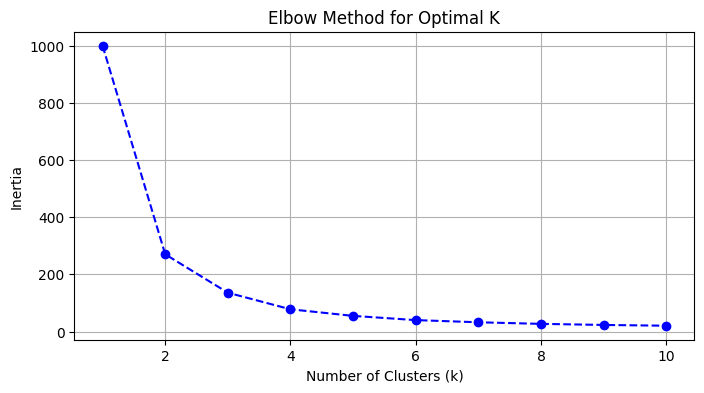

In [ ]:
#CLUSTERING TASK - ELBOW METHOD (UNSUPERVISED)
# 1. Scale data
cluster_features = housing_df[["SquareFeet", "Price"]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_features)

# 2. Find optimal K via Elbow Method
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker="o", linestyle="--", color="b")
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

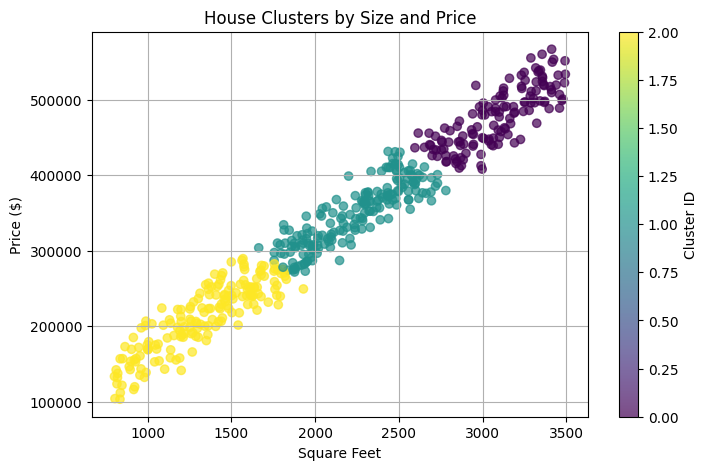

In [ ]:
#  CLUSTERING VISUALIZATION
# Fit final model (e.g., K = 3)
chosen_k = 3
kmeans_final = KMeans(n_clusters=chosen_k, random_state=42, n_init=10)
housing_df["Cluster"] = kmeans_final.fit_predict(X_scaled)

# Plot Clusters
plt.figure(figsize=(8, 5))
scatter = plt.scatter(
    housing_df["SquareFeet"],
    housing_df["Price"],
    c=housing_df["Cluster"],
    cmap="viridis",
    alpha=0.7,
)
plt.colorbar(scatter, label="Cluster ID")
plt.title("House Clusters by Size and Price")
plt.xlabel("Square Feet")
plt.ylabel("Price ($)")
plt.grid(True)
plt.show()